In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Model
from pmdarima import auto_arima
from prophet import Prophet

In [42]:
train = pd.read_csv(r'D:\Kitab Suci\Fixxxx belajar\Machine Learning\Dataset\Demand-forecasting\train.csv', parse_dates=['date'])
train

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10
...,...,...,...,...
912995,2017-12-27,10,50,63
912996,2017-12-28,10,50,59
912997,2017-12-29,10,50,74
912998,2017-12-30,10,50,62


In [43]:
train.info()
train.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[ns]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 27.9 MB


(913000, 4)

In [44]:
train.dtypes

date     datetime64[ns]
store             int64
item              int64
sales             int64
dtype: object

In [45]:
train.isnull().sum()

date     0
store    0
item     0
sales    0
dtype: int64

In [46]:
train.describe()

,date,store,item,sales
count,913000,913000.000000,913000.000000,913000.000000
mean,2015-07-02 11:59:59.999999744,5.500000,25.500000,52.250287
min,2013-01-01 00:00:00,1.000000,1.000000,0.000000
25%,2014-04-02 00:00:00,3.000000,13.000000,30.000000
50%,2015-07-02 12:00:00,5.500000,25.500000,47.000000
75%,2016-10-01 00:00:00,8.000000,38.000000,70.000000
max,2017-12-31 00:00:00,10.000000,50.000000,231.000000
std,NaN,2.872283,14.430878,28.801144


count    1826.000000
mean       19.971522
std         6.741022
min         4.000000
25%        15.000000
50%        19.000000
75%        24.000000
max        50.000000
Name: sales, dtype: float64


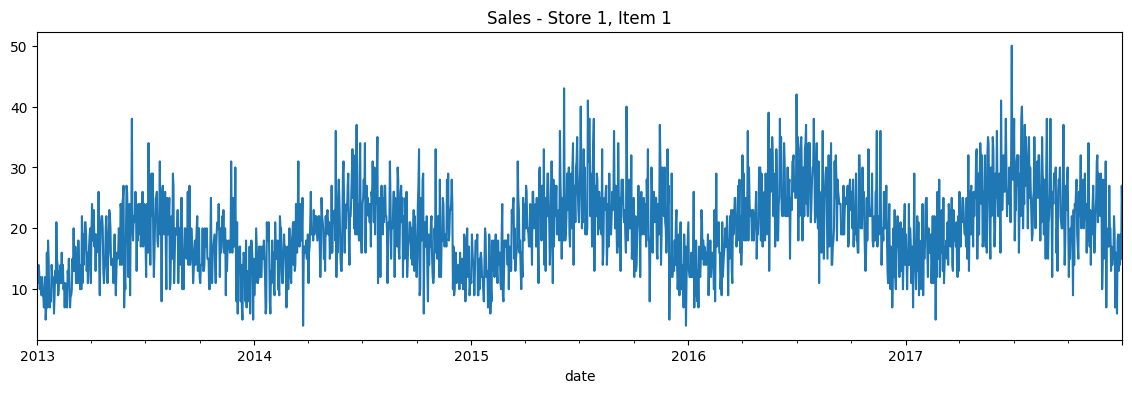

In [47]:
ts = train[(train['store'] == 1) & (train['item'] == 1)].copy()
ts = ts.set_index('date').sort_index()['sales']

print(ts.describe())
ts.plot(figsize=(14, 4), title='Sales - Store 1, Item 1')
plt.show()

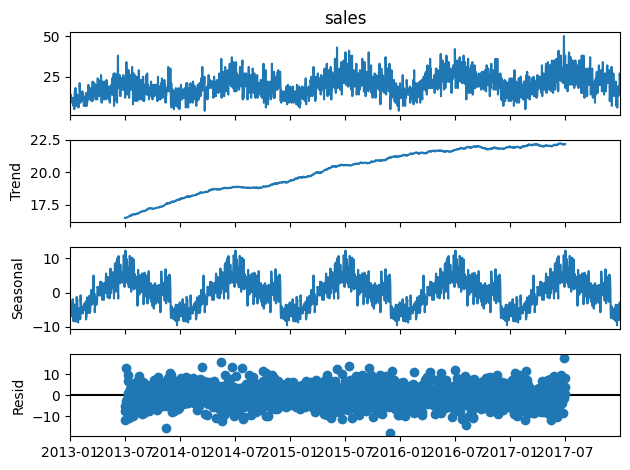

In [48]:
decomp = seasonal_decompose(ts, model='additive', period=365)
decomp.plot()
plt.tight_layout()
plt.show()

In [49]:
result = adfuller(ts)
print(f'ADF Statistic : {result[0]:.4f}')
print(f'p-value       : {result[1]:.4f}')

ADF Statistic : -3.1577
p-value       : 0.0226


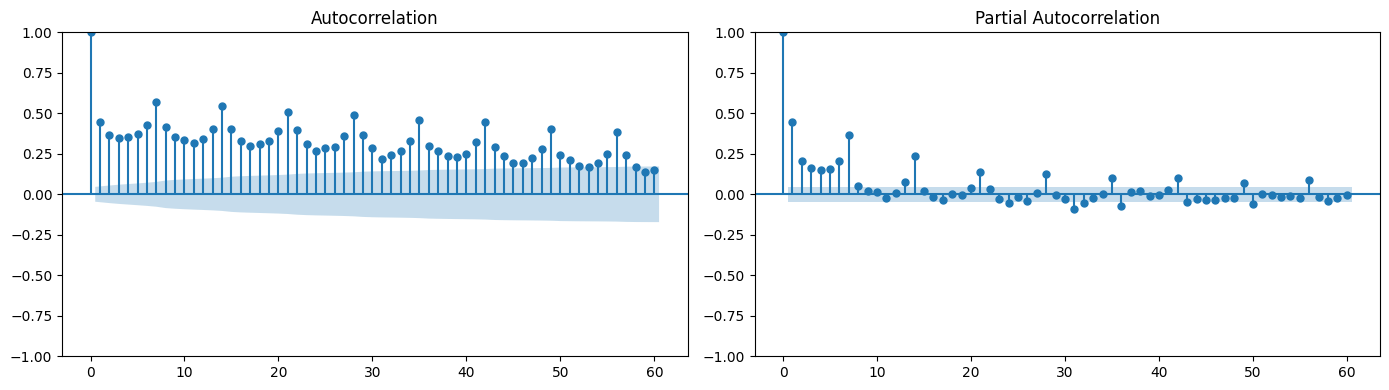

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ts, lags=60, ax=axes[0])   # → tentukan parameter q, Q
plot_pacf(ts, lags=60, ax=axes[1])  # → tentukan parameter p, P
plt.tight_layout()
plt.show()

Train: 2013-01-01 s/d 2016-12-31 (1461 hari)
Test : 2017-01-01 s/d 2017-12-31 (365 hari)


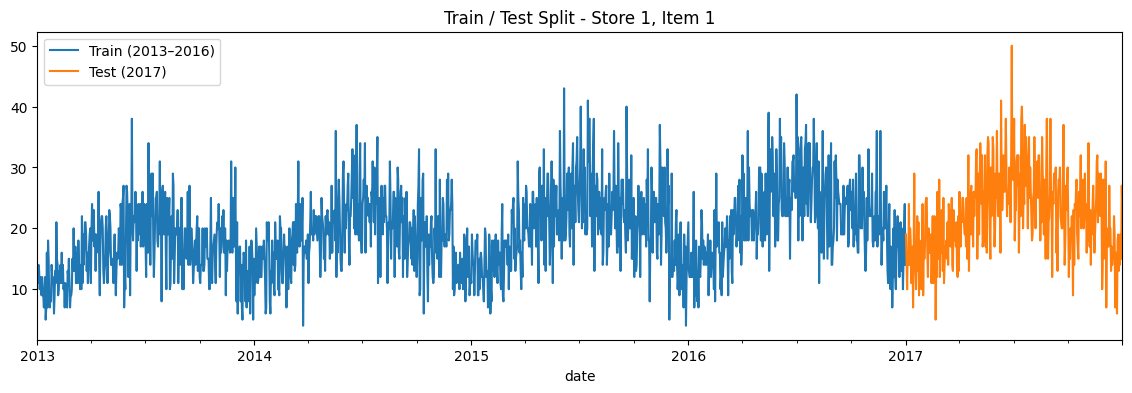

In [51]:
train_ts = ts[:'2016-12-31']   # 2013–2016 = 4 tahun
test_ts  = ts['2017-01-01':]   # 2017 = 1 tahun

print(f'Train: {train_ts.index.min().date()} s/d {train_ts.index.max().date()} ({len(train_ts)} hari)')
print(f'Test : {test_ts.index.min().date()} s/d {test_ts.index.max().date()} ({len(test_ts)} hari)')

# Visualisasi split
plt.figure(figsize=(14, 4))
train_ts.plot(label='Train (2013–2016)')
test_ts.plot(label='Test (2017)')
plt.legend()
plt.title('Train / Test Split - Store 1, Item 1')
plt.show()

In [52]:
# Prophet butuh kolom 'ds' dan 'y'
df_prophet = train_ts.reset_index()
df_prophet.columns = ['ds', 'y']

print(df_prophet.head())

          ds   y
0 2013-01-01  13
1 2013-01-02  11
2 2013-01-03  14
3 2013-01-04  13
4 2013-01-05  10


14:20:24 - cmdstanpy - INFO - Chain [1] start processing
14:20:24 - cmdstanpy - INFO - Chain [1] done processing


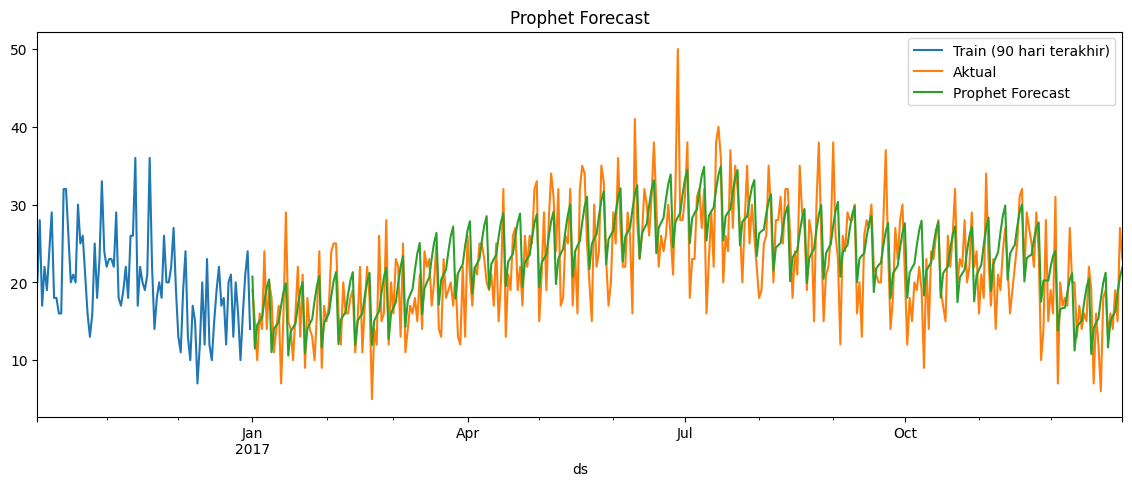

In [53]:
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.05,   # coba 0.01, 0.05, 0.1, 0.5
    seasonality_prior_scale=10,     # coba 1, 5, 10
    changepoint_range=0.9           # gunakan 90% data untuk deteksi tren
)

prophet_model.fit(df_prophet)

# Buat dataframe future sejumlah hari test
future = prophet_model.make_future_dataframe(periods=len(test_ts))
forecast = prophet_model.predict(future)

# Ambil bagian test saja
prophet_pred = forecast[['ds', 'yhat']].tail(len(test_ts))
prophet_pred = prophet_pred.set_index('ds')['yhat']

# Visualisasi
plt.figure(figsize=(14, 5))
train_ts[-90:].plot(label='Train (90 hari terakhir)')
test_ts.plot(label='Aktual')
prophet_pred.plot(label='Prophet Forecast')
plt.legend()
plt.title('Prophet Forecast')
plt.show()

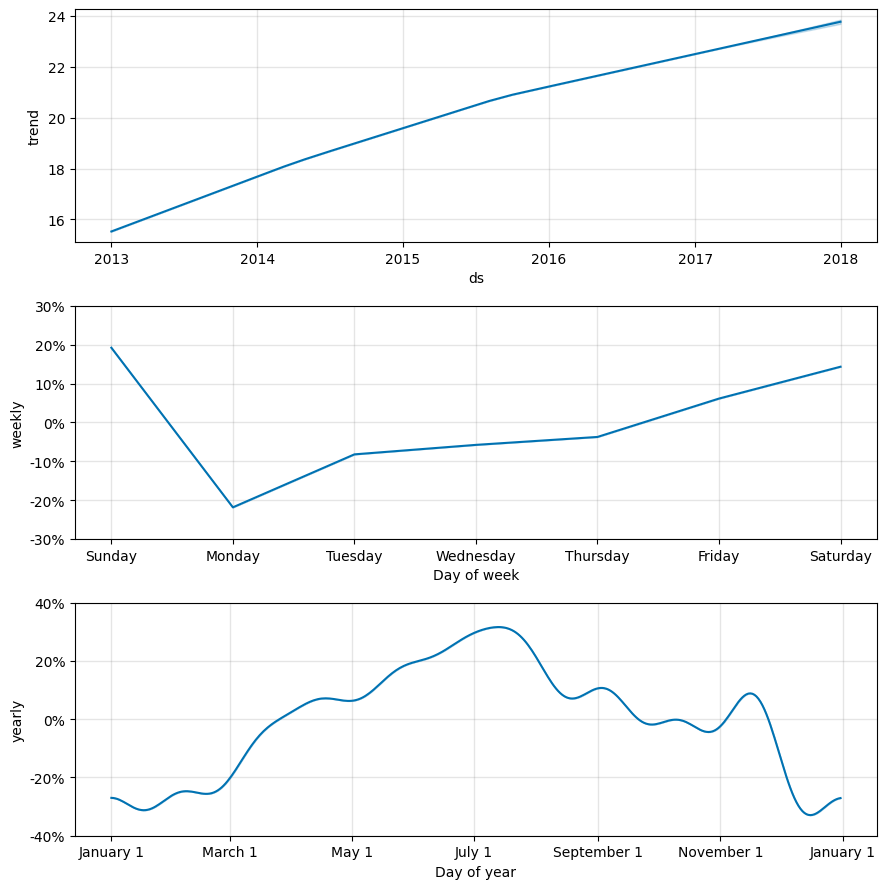

In [54]:
# Lihat trend, weekly, yearly secara terpisah
prophet_model.plot_components(forecast)
plt.show()

In [55]:
def mape(actual, predicted):
    return np.mean(np.abs((actual - predicted) / actual)) * 100

# Hitung metrik
actuals = test_ts.values


mae_prophet  = mean_absolute_error(actuals, prophet_pred.values)
rmse_prophet = np.sqrt(mean_squared_error(actuals, prophet_pred.values))
mape_prophet = mape(actuals, prophet_pred.values)

# Tampilkan perbandingan
results = pd.DataFrame({
    'Model' : [ 'Prophet'],
    'MAE'   : [ mae_prophet],
    'RMSE'  : [ rmse_prophet],
    'MAPE %': [mape_prophet]
})

print(results.to_string(index=False))

  Model      MAE     RMSE    MAPE %
Prophet 3.975113 4.895519 21.195741
